# Phase 1 — Calibrating the prior concentration s to q

Sibling of `1b`, which swept the gap $\Delta$ and found that narrowing it lowers $q = P(D_i)$ only toward $\approx\tfrac12$ for the last-$k$ and posterior-gap criteria. This notebook turns the **other** knob: the prior. It fixes the gap $\Delta$ and horizon $T$ and sweeps the prior concentration $s$ in $\mathrm{Beta}(s,s)$, Monte-Carloing $q$ under both criteria, producing a curve $q(s)$ and an **inverse** $s(q)$ so you can pick the prior that yields a target such as $q = 0.05$.

The criterion threshold is set as $\delta = \Delta / 2$, strictly below the true gap. The agents are **myopic and greedy** — each step they pull the arm with the higher posterior mean, with no exploration bonus — so learning is *incomplete*: once an agent abandons an arm, that arm's posterior freezes, and an unlucky early run can lock the agent onto the worse arm $B$ permanently. Consequently $q$ does **not** climb to $1$ as $T \to \infty$; it plateaus at the fraction of agents that commit to $A$, strictly below $1$ (see the closing **What this shows** cell). The lever this notebook uses is different: at a **fixed** horizon $T$, a strong prior holds beliefs near $\tfrac12$ for longer than $T$, so few agents ever reach the discovery threshold and $q$ falls toward $0$. That is what makes $q = 0.05$ reachable by choosing $s$ — and why raising $T$ would push the required $s$ *up*, not improve "convergence".

**Restart-and-Run-All-safe.** The sweep is wrapped in `%%time`; `tqdm` shows progress. Flip `SMOKE_TEST = True` for a fast end-to-end check.

## Setup

Local-only (no Colab/Drive). Imports from `model/` in the parent paper folder.

> **Env note.** If the next cell prints a `NumPy 1.x cannot be run in NumPy 2.x` traceback referencing `numexpr`, imports still succeeded (pandas treats it as optional) — silence with `python3 -m pip install -U "numexpr>=2.10"` and restart the kernel.

In [1]:
import sys
from datetime import datetime
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.interpolate import PchipInterpolator
from scipy.optimize import brentq
from tqdm.auto import tqdm

PAPER_ROOT = Path.cwd().resolve().parent
if str(PAPER_ROOT) not in sys.path:
    sys.path.insert(0, str(PAPER_ROOT))
RESULTS_DIR = PAPER_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

from model.bandit import ARM_A, ARM_B, BernoulliBandit
from model.discovery import discovered_by_last_k, discovered_by_posterior_gap
from model.simulation import run_simulation

## Parameters

The gap and horizon are now held **fixed** and the prior strength is the swept knob. The calibration is conditional on `GAP` and `N_STEPS`: retarget at a different gap or horizon by changing them and re-running. `S_GRID` is log-spaced and chosen to bracket where posterior-gap $q$ crosses the target.

In [2]:
SMOKE_TEST = False         # True -> tiny run for kernel-restart smoke tests

# Fixed context: arms centered at P_MID, pulled apart by GAP.
# GAP=0.05 is the chosen operating point: with delta=GAP/2 the q=0.05 target
# is reached at a MODEST prior (s ~ 800 here) that stays well under 5000 even
# as the horizon grows -- unlike GAP=0.01, where the required s runs past 5000
# for T beyond ~3000. See the (Delta, T, s) feasibility map that motivated it.
P_MID = 0.5
GAP   = 0.05               # Delta = p_A - p_B  (p_A=0.525, p_B=0.475 by default)

# Monte Carlo budget. Each agent is an i.i.d. draw of D_i in the unaided
# regime, so N_AGENTS is the number of samples of q per prior strength.
# (q's standard error is sqrt(q(1-q)/N_AGENTS); raise N_AGENTS to tighten
# the error bars -- it does NOT change the underlying q, only its estimate.)
N_AGENTS = 50 if SMOKE_TEST else 300
N_STEPS  = 80  if SMOKE_TEST else 1000     # horizon T (held fixed across sweep)

# The swept knob: prior is Beta(s, s) per arm (uniform-but-concentrated as s
# grows). s=1 is the flat Beta(1,1) baseline; large s pins beliefs near 1/2,
# so at the FIXED horizon T few agents ever move off indifference and q -> 0.
# Grid is dense around s ~ 800 (the predicted q=0.05 crossing at GAP=0.05,
# T=1000) so the inverter brackets the target cleanly; it tops out at 5000.
if SMOKE_TEST:
    S_GRID = np.array([1, 100, 1000, 5000])
else:
    S_GRID = np.array([1, 100, 300, 500, 800, 1200, 2000, 5000])

# Discovery-criterion tolerances (held fixed).
LAST_K_WINDOW = 20         # last-k: last k pulls all arm A
# Posterior-gap criterion: E[p_A|h] - E[p_B|h] >= GAP_DELTA, with delta set
# strictly below the true gap (delta = GAP / 2). NOTE: the agents are greedy,
# so learning is incomplete -- q does NOT approach 1 as T grows; a permanent
# fraction of agents lock onto the worse arm. The calibration is therefore a
# genuine finite-T property: at horizon T, how strong a prior holds q to
# TARGET_Q. Raising N_STEPS pushes the required s UP, not down.
GAP_DELTA     = GAP / 2

TARGET_Q    = 0.05         # the q we want to hit by choosing s
MASTER_SEED = 2026

print(f'SMOKE_TEST={SMOKE_TEST}  gap={GAP}  gap_delta={GAP_DELTA}  '
      f'n_agents/s={N_AGENTS}  n_steps={N_STEPS}  '
      f'#s={len(S_GRID)}  target_q={TARGET_Q}  seed={MASTER_SEED}')

SMOKE_TEST=False  gap=0.05  gap_delta=0.025  n_agents/s=300  n_steps=1000  #s=8  target_q=0.05  seed=2026


## Discovery criteria (vectorized)

Same vectorized forms of `discovered_by_last_k` and `discovered_by_posterior_gap` as `1b`; the next cell asserts they match the per-agent module functions on a sample.

In [3]:
def discovery_masks(histories, final_alpha_beta, *, k, delta):
    """Vectorized last-k and posterior-gap criteria over a whole community.

    histories:        (M, T, 2) int   rows [arm_pulled, outcome]
    final_alpha_beta: (M, 2, 2) float per-agent final Beta params
    Returns {criterion -> (M,) bool array of D_i outcomes}.
    """
    last_k = np.all(histories[:, -k:, 0] == ARM_A, axis=1)
    means = final_alpha_beta[:, :, 0] / final_alpha_beta.sum(axis=2)
    gap = (means[:, ARM_A] - means[:, ARM_B]) >= delta
    return {'last_k': last_k, 'posterior_gap': gap}

In [4]:
_chk = run_simulation(BernoulliBandit(p_a=0.6, p_b=0.4),
                      n_agents=50, n_steps=60, seed=0)
_vec = discovery_masks(_chk.histories, _chk.final_alpha_beta,
                       k=LAST_K_WINDOW, delta=GAP_DELTA)
_ref_lastk = np.array([
    discovered_by_last_k(_chk.histories[i], _chk.final_alpha_beta[i], k=LAST_K_WINDOW)
    for i in range(_chk.n_agents)])
_ref_gap = np.array([
    discovered_by_posterior_gap(_chk.histories[i], _chk.final_alpha_beta[i], delta=GAP_DELTA)
    for i in range(_chk.n_agents)])
assert np.array_equal(_vec['last_k'], _ref_lastk)
assert np.array_equal(_vec['posterior_gap'], _ref_gap)
print('vectorized criteria match discovery.py on the sample')

vectorized criteria match discovery.py on the sample


## Run the prior-strength sweep

For each $s$ we run one community of `N_AGENTS` independent agents that all start from a shared $\mathrm{Beta}(s,s)$ prior on each arm, at the fixed gap `GAP` for `N_STEPS` steps, and record $\hat q$ with its binomial standard error under each criterion.

In [5]:
%%time
p_a = P_MID + GAP / 2
p_b = P_MID - GAP / 2
bandit = BernoulliBandit(p_a=p_a, p_b=p_b)

ss = np.random.SeedSequence(MASTER_SEED)
s_seeds = [int(x.generate_state(1)[0]) for x in ss.spawn(len(S_GRID))]

rows = []
for s, seed in zip(tqdm(S_GRID, desc='prior sweep'), s_seeds):
    prior = np.array([[s, s], [s, s]], dtype=float)
    res = run_simulation(bandit=bandit, n_agents=N_AGENTS, n_steps=N_STEPS,
                         prior_alpha_beta=prior, seed=seed)
    masks = discovery_masks(res.histories, res.final_alpha_beta,
                            k=LAST_K_WINDOW, delta=GAP_DELTA)
    for name, mask in masks.items():
        q = float(mask.mean())
        rows.append({
            's': float(s), 'criterion': name, 'q_hat': q,
            'se': float(np.sqrt(q * (1 - q) / N_AGENTS)),
        })

calib = pd.DataFrame(rows)
calib_wide = calib.pivot(index='s', columns='criterion', values='q_hat')
calib_wide

prior sweep:   0%|          | 0/8 [00:00<?, ?it/s]

CPU times: user 47.8 s, sys: 911 ms, total: 48.7 s
Wall time: 58.2 s


criterion,last_k,posterior_gap
s,,
1.0,0.603333,0.573333
100.0,0.903333,0.633333
300.0,0.906667,0.296667
500.0,0.910000,0.070000
800.0,0.923333,0.010000
1200.0,0.936667,0.000000
2000.0,0.933333,0.000000
5000.0,0.930000,0.000000


## The calibration curve $q(s)$

figure -> results/phase1_prior_q_curve_20260531_163926.png


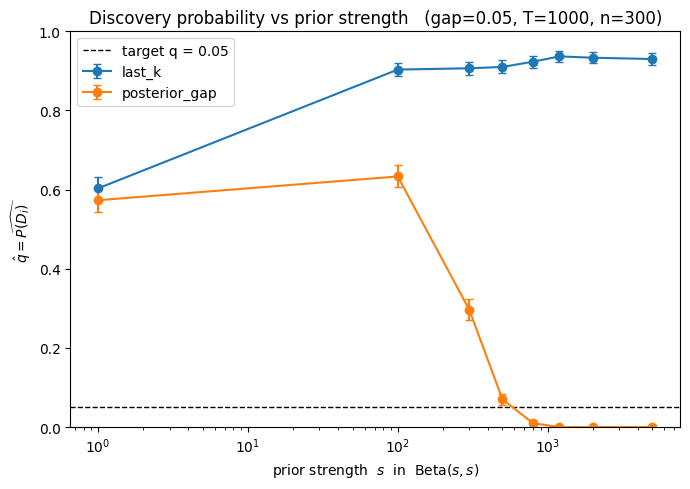

In [6]:
fig, ax = plt.subplots(figsize=(7, 5))
for name, grp in calib.groupby('criterion'):
    ax.errorbar(grp['s'], grp['q_hat'], yerr=grp['se'],
                marker='o', capsize=3, label=name)
ax.axhline(TARGET_Q, color='black', ls='--', lw=1, label=f'target q = {TARGET_Q}')
ax.set_xscale('log')
ax.set_xlabel(r'prior strength  $s$  in  $\mathrm{Beta}(s,s)$')
ax.set_ylabel(r'$\hat q = \widehat{P(D_i)}$')
ax.set_title(f'Discovery probability vs prior strength   (gap={GAP}, T={N_STEPS}, n={N_AGENTS})')
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
fig_path = RESULTS_DIR / f'phase1_prior_q_curve_{stamp}.png'
plt.savefig(fig_path, dpi=150)
print(f'figure -> {fig_path.relative_to(PAPER_ROOT)}')
plt.show()

## Invert: which prior strength s gives a target q?

We fit a monotone-aware (PCHIP) interpolant $q(s)$ per criterion and invert it by a sign-change scan plus a bracketed root find (robust to the small non-monotone bump posterior-gap shows at low $s$, and to MC noise). `s_for_q(target)` returns the prior strength realising `target`, or `None` if `target` is outside the range of $q$ on the grid.

In [7]:
def make_inverter(s_grid, q_vals):
    """Return (s_for_q, (q_min, q_max)) for one criterion.

    PCHIP interpolation of q(s); inversion by scanning for the first sign
    change of q(s) - target (robust to non-monotonicity), then brentq.
    s_for_q(target) -> the s giving q = target, or None when target is
    outside the achievable range [q_min, q_max] spanned by the grid.
    """
    order = np.argsort(s_grid)
    s = np.asarray(s_grid)[order]
    q = np.asarray(q_vals)[order]
    f = PchipInterpolator(s, q)
    q_min, q_max = float(q.min()), float(q.max())

    def s_for_q(target):
        if not (q_min <= target <= q_max):
            return None
        g = lambda x: float(f(x)) - target
        xs = np.linspace(s[0], s[-1], 800)
        vals = np.array([g(x) for x in xs])
        crossings = np.where(np.diff(np.sign(vals)) != 0)[0]
        if len(crossings) == 0:
            return float(xs[np.argmin(np.abs(vals))])
        i = crossings[0]
        return float(brentq(g, xs[i], xs[i + 1]))

    return s_for_q, (q_min, q_max)


print(f'Prior strength s needed for q = {TARGET_Q}  '
      f'(gap={GAP}, T={N_STEPS}, k={LAST_K_WINDOW}, gap_delta={GAP_DELTA}):')
print()

inverters = {}
for name, grp in calib.groupby('criterion'):
    inv, (q_min, q_max) = make_inverter(grp['s'].values, grp['q_hat'].values)
    inverters[name] = inv
    s_star = inv(TARGET_Q)
    if s_star is None:
        print(f'  {name:14s}:  q stays in [{q_min:.3f}, {q_max:.3f}] over the grid; '
              f'q={TARGET_Q} is OUT OF RANGE.')
    else:
        print(f'  {name:14s}:  s ~ {s_star:.1f}   '
              f'(prior Beta({s_star:.0f}, {s_star:.0f}) per arm)')

Prior strength s needed for q = 0.05  (gap=0.05, T=1000, k=20, gap_delta=0.025):

  last_k        :  q stays in [0.603, 0.937] over the grid; q=0.05 is OUT OF RANGE.
  posterior_gap :  s ~ 561.7   (prior Beta(562, 562) per arm)


## Save

Persist the calibration as a timestamped CSV under [`results/`](../results/) so the $s \leftrightarrow q$ map can be reused without recomputing.

In [8]:
stamp = datetime.now().strftime('%Y%m%d_%H%M%S')
csv_path = RESULTS_DIR / f'phase1_prior_q_calibration_{stamp}.csv'
calib.to_csv(csv_path, index=False)
print(f'calibration table -> {csv_path.relative_to(PAPER_ROOT)}')
print(f'figure            -> {fig_path.relative_to(PAPER_ROOT)}')

calibration table -> results/phase1_prior_q_calibration_20260531_163927.csv
figure            -> results/phase1_prior_q_curve_20260531_163926.png


## What this shows, and how to use it

- **Agents are greedy, so learning is incomplete.** Each agent pulls the higher posterior mean with no exploration bonus. Once it abandons an arm, that arm's posterior freezes, and an unlucky early run can lock the agent onto the worse arm $B$ forever. So $q = P(D_i)$ does **not** converge to $1$ as $T \to \infty$ — it plateaus at the fraction that commits to $A$, strictly below $1$, with the rest split between agents still undecided and agents permanently stuck on $B$. (Long-horizon check at this gap: with $s=1$, posterior-gap $q$ is already frozen at $\approx 0.54$ by $T=1000$ and does not move through $T=20000$.)
- **Prior concentration is the lever for $q = 0.05$ at fixed $T$.** A strong prior $\mathrm{Beta}(s,s)$ needs $\sim s$ observations to move off $\tfrac12$. At horizon $T$, large $s$ keeps most agents near indifference so they never clear the threshold, pushing **both** criteria toward $0$. At `GAP=0.01`, $T=1000$, $\delta=\Delta/2$ the posterior-gap $q$ falls from $\approx 0.5$ ($s=1$) through the $q=0.05$ target near $s \approx 3000$ to $\approx 0$ ($s=5000$). The inversion cell reports the exact $s$; read future targets off it or the saved CSV.
- **Horizon and prior trade off — keeping $s$ small needs $T$ small.** Because more data moves even a strong prior, raising $T$ pushes the $s$ needed for a fixed $q$ **up**, not down. At $T=5000$ the $q=0.05$ crossing lands near $s \approx 7300$; at $T=1000$ it is near $s \approx 3000$. So $T=1000$ is the choice that keeps the calibrated prior within $s \le 5000$. Increasing $T$ does **not** "improve convergence" here — under incomplete learning there is no $q\to1$ limit to converge to.
- **Both criteria fall with $s$ — note *why*.** At moderate $s$ relative to $T$ the agents commit, and last-$k$ tracks the committed-to-$A$ fraction (near $\tfrac12$). At large $s$ the agents never commit within $T$: their pulls keep flip-flopping near a tie, so the last $k$ pulls are almost never all-$A$ and last-$k$ $\to 0$ as well. The two criteria co-move down with $s$ here rather than decoupling.
- **Consistency with the paper (§2).** This matches the paper's *An analytic handle as $T \to \infty$* paragraph: under myopic play each agent eventually absorbs on a single arm, so both criteria converge to $P(\text{settle on } A)$, which lies strictly between $0$ and $1$ — below $1$ by incomplete learning, above $0$ because a good early run locks onto $A$. The criteria are asymptotically equivalent at *that* common value, **not** at $1$.
- **Interpretation.** A large-$s$ prior models agents who are a priori confident the arms are similar and demand substantial evidence to be moved; at horizon $T$ they mostly fail the discovery test. That is the regime in which individual discovery is genuinely rare, while — by §2's independence argument, which *fixes* $q$ and varies $n$ — a large community still very likely discovers $A$.
- **Retargeting.** Change `GAP`, `GAP_DELTA` (kept at $\Delta/2$ as a convention), or `N_STEPS` and re-run to recalibrate $s$. Raising `N_STEPS` pushes the required $s$ **up**, so keep $T$ fixed (and modest) when you want a small $s$.